# AstroCLIMB - GLM-4.6V-Flash Baseline (Kaggle Ready, Balanced 1800)
**Model:** `zai-org/GLM-4.6V-Flash` (9B Flash, latest 2025-12-08, 128K, not Qwen). **Kaggle-ready** `GPU T4 x2`, **balanced 5-7h**.
**Fix:** Uses `AutoModel` (GLM, not Qwen3VLForConditionalGeneration), `AutoProcessor` with `Glm46VImageProcessor`, no Qwen class mismatch.
**Classes:** `same_figure, same_paper, related_papers, unrelated_papers`


In [1]:
# --- 1. Setup + Kaggle-ready install (run once, auto-restart if needed) ---
import os, json, time, re, gc, base64, sys, subprocess, importlib
from pathlib import Path
from io import BytesIO
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from PIL import Image
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import torch
print("torch", torch.__version__, "cuda", torch.cuda.is_available())
if torch.cuda.is_available():
    print([torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())])
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    print("NO GPU - Kaggle: Settings -> Accelerator -> GPU T4 x2 -> Save Version & Rerun")
import transformers
print(f"transformers {transformers.__version__}")
# Auto-fix bitsandbytes missing (your log: ImportError bitsandbytes>=0.46.1 at 194.2s)
try:
    import bitsandbytes
    print(f"bitsandbytes {bitsandbytes.__version__} OK")
except ImportError:
    print("bitsandbytes missing, installing...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "bitsandbytes>=0.46.1"])
    import bitsandbytes
    print(f"bitsandbytes {bitsandbytes.__version__} installed")
# Qwen3-VL config check (needs git transformers)
try:
    from transformers.models.qwen3_vl.configuration_qwen3_vl import Qwen3VLConfig
    print("Qwen3-VL config OK")
except Exception as e:
    print(f"Qwen3-VL not supported ({e}), installing transformers from source...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/huggingface/transformers.git", "accelerate"])
    print("Installed git transformers - RESTART kernel now: Kernel -> Restart & Clear Output, then rerun")
    raise SystemExit("Restart required")


torch 2.10.0+cu128 cuda True
['Tesla T4', 'Tesla T4']
VRAM: 15.6 GB
transformers 5.0.0
bitsandbytes missing, installing...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 43.1 MB/s eta 0:00:00
bitsandbytes 0.50.2 installed
Qwen3-VL config OK


In [2]:
# --- 2. Data loading (Kaggle competitions path, train-only) ---
train = pd.read_csv("/kaggle/input/competitions/astroclimb/train.csv")
print(f"train {train.shape}")
print(train.columns.tolist())
display(train.head(2))
label_cols = ["same_figure","same_paper","related_papers","unrelated_papers"]
train["label"] = train[label_cols].idxmax(axis=1)
train["label_id"] = train["label"].map({c:i for i,c in enumerate(label_cols)})
print(train["label"].value_counts())
print(train[label_cols].sum())


train (10000, 7)
['id', 'same_figure', 'same_paper', 'related_papers', 'unrelated_papers', 'obj_1', 'obj_2']


,id,same_figure,same_paper,related_papers,unrelated_papers,obj_1,obj_2
0,0,1,0,0,0,Distribution of the RVs for TOI-2046b in the t...,iVBORw0KGgoAAAANSUhEUgAACVYAAAZUCAIAAACPYVwUAA...
1,1,1,0,0,0,Vertical structures of the Martian background ...,iVBORw0KGgoAAAANSUhEUgAABwgAAAQ2CAIAAACoaX6RAA...


label
same_paper          3000
related_papers      3000
unrelated_papers    3000
same_figure         1000
Name: count, dtype: int64
same_figure         1000
same_paper          3000
related_papers      3000
unrelated_papers    3000
dtype: int64


In [3]:
# --- 3. Helpers: detect image vs text + decode (train only) ---
def is_image_str(s):
    if not isinstance(s, str) or len(s) < 200:
        return False
    return s.strip().startswith("iVBORw0KGgo")  # PNG base64 header (JPEG would be /9j/)

def convert_str_to_PIL(img_str):
    return Image.open(BytesIO(base64.b64decode(img_str))).convert("RGB")

train["obj_1_is_img"] = train["obj_1"].apply(is_image_str)
train["obj_2_is_img"] = train["obj_2"].apply(is_image_str)
train["pair_type"] = train.apply(lambda r: ("IMG" if r["obj_1_is_img"] else "TXT") + "-" + ("IMG" if r["obj_2_is_img"] else "TXT"), axis=1)
print(train["pair_type"].value_counts())


pair_type
TXT-IMG    4000
IMG-IMG    3000
TXT-TXT    3000
Name: count, dtype: int64


In [4]:
# --- 3b. Balanced sampler for 5-7h session (per-class + pairwise per class) ---
# 5-7h = 1500-2100 samples at 12s/it. Choose 450/class => 1800 total = ~6.3h (center)
# same_figure only has TXT-IMG (1000 total), so it will be 450 TXT-IMG / 0 others. Others: 150 per pair_type.
def sample_balanced(df, n_per_class=450, seed=42):
    import pandas as pd
    assert n_per_class % 3 == 0, "n_per_class must be divisible by 3 for 3-type classes"
    parts = []
    for label in ["same_figure","same_paper","related_papers","unrelated_papers"]:
        sub = df[df["label"]==label]
        if label == "same_figure":
            # Only TXT-IMG exists for same_figure
            parts.append(sub[sub["pair_type"]=="TXT-IMG"].sample(n=n_per_class, random_state=seed))
        else:
            per_pair = n_per_class // 3
            for pt in ["TXT-IMG","IMG-IMG","TXT-TXT"]:
                g = sub[sub["pair_type"]==pt]
                if len(g) < per_pair:
                    print(f"Warning: {label} {pt} has {len(g)} < {per_pair}, taking all")
                    parts.append(g)
                else:
                    parts.append(g.sample(n=per_pair, random_state=seed))
    bal = pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)
    return bal

train_bal = sample_balanced(train, n_per_class=450, seed=42)
print(f"train_bal {train_bal.shape} (target 1800 = 450*4)")
print(train_bal["label"].value_counts())
print(pd.crosstab(train_bal["label"], train_bal["pair_type"]))
print(f"Estimated time: {len(train_bal)*12.5/3600:.1f}h at 12.5s/it")


train_bal (1800, 12) (target 1800 = 450*4)
label
unrelated_papers    450
related_papers      450
same_paper          450
same_figure         450
Name: count, dtype: int64
pair_type         IMG-IMG  TXT-IMG  TXT-TXT
label                                      
related_papers        150      150      150
same_figure             0      450        0
same_paper            150      150      150
unrelated_papers      150      150      150
Estimated time: 6.2h at 12.5s/it


### 4. Task (multi-class, single-label, symmetrical)
Inputs = pairs of objects: `two figures` / `figure + caption` / `two captions`. Exactly **one** label per pair, relation is symmetrical (A vs B == B vs A).

- **same_figure**: two objects are from the SAME scientific figure (only for figure+caption pairs)
- **same_paper**: same paper (same DOI), different figures
- **related_papers**: one DOI cites the other
- **unrelated_papers**: none of the above

Train has only `obj_1, obj_2` + 4 one-hot label cols -> model must infer DOI/citation **from content only** (no metadata). System prompt below is **descriptive**, not hard constraints; test hood unknown so we do not mask labels.


In [5]:
# Descriptive prompt - no metadata, infer from content only (no DOI leaked, no hard same_figure constraint)
SYSTEM_PROMPT = """You are an expert in astrophysics figures and captions. Given Object A and Object B (each is either a figure image or a caption text), classify their relation into exactly ONE label based ONLY on what you see/read - no DOI or metadata is provided.

Classes:
- same_figure: The caption directly describes the figure in front of you. Visual elements (axes, labels, numbers, morphology) are mentioned verbatim in the text, or the text reads like "Figure X shows..." matching the image.
- same_paper: Same study, different figures. Similar writing style, same instruments/datasets/authors hinted in text, or visual style (fonts, colors, layout) is consistent, but NOT a direct caption-figure match.
- related_papers: Different papers where one builds on the other. Overlapping methods, shared datasets, or a figure/caption that looks like a cited prior result, but style/authors differ.
- unrelated_papers: No clear link. Different topics, instruments, scales, or writing/visual style with no overlap.

Base your decision only on visual and textual content. Do not assume same_figure is impossible for any pair type - judge from alignment.
Output ONLY the lowercase label (e.g., related_papers), no explanation, no punctuation.
"""

def build_user_content(row):
    parts = []
    for col, name in [("obj_1","Object A"), ("obj_2","Object B")]:
        s = row[col]
        if row[f"{col}_is_img"]:
            parts.append({"name": name, "is_img": True, "pil": convert_str_to_PIL(s)})
        else:
            txt = str(s)[:2000]
            parts.append({"name": name, "is_img": False, "text": txt})
    return parts

print(SYSTEM_PROMPT[:400])
print(build_user_content(train.iloc[0])[0].keys())


You are an expert in astrophysics figures and captions. Given Object A and Object B (each is either a figure image or a caption text), classify their relation into exactly ONE label based ONLY on what you see/read - no DOI or metadata is provided.

Classes:
- same_figure: The caption directly describes the figure in front of you. Visual elements (axes, labels, numbers, morphology) are mentioned ve
dict_keys(['name', 'is_img', 'text'])


In [6]:
# --- 5. Model loading - GLM-4.6V-Flash (strict, no fallback) ---
# No fallback: this notebook runs ONLY zai-org/GLM-4.6V-Flash (9B)
# WARNING: 9B bf16 ~18GB > T4 15.6GB -> will OOM on Kaggle T4 x2 even with 4-bit offload
# If OOM, use SmolVLM-500M_baseline.ipynb or Qwen3-VL-4B instead (4B fits T4)
from transformers import AutoProcessor, AutoTokenizer
try:
    from transformers import AutoModelForImageTextToText
    ModelClass = AutoModelForImageTextToText
    print("Using AutoModelForImageTextToText")
except ImportError:
    from transformers import AutoModel
    ModelClass = AutoModel
    print("Fallback AutoModel")
import torch
MODEL_ID = "zai-org/GLM-4.6V-Flash"
ENABLE_THINKING = False
BATCH_SIZE = 1
MAX_NEW_TOKENS = 32
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading {MODEL_ID} batch={BATCH_SIZE} on {device}")
if device=="cpu":
    raise SystemExit("Enable GPU T4 x2")
processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)
print("Processor", type(processor).__name__)
try:
    from transformers import BitsAndBytesConfig
    bnb_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True)
    model = ModelClass.from_pretrained(MODEL_ID, device_map="auto", quantization_config=bnb_config, max_memory={0:"10GB", 1:"10GB"}, trust_remote_code=True)
    print("Model 4-bit", type(model).__name__)
except Exception as e:
    print(f"4-bit failed {e}, trying bf16 sharded 10GB")
    model = ModelClass.from_pretrained(MODEL_ID, dtype="bfloat16", device_map="auto", max_memory={0:"10GB", 1:"10GB"}, trust_remote_code=True)
    print("Model bf16", type(model).__name__)
    print("NOTE: If this still OOMs (4.41 GiB scaled_dot_product), T4 cannot run 9B - use Qwen3-VL-4B/SmolVLM")
model.eval()
print("Model", type(model).__name__, "Has chat:", hasattr(model, 'chat'), "Has generate:", hasattr(model, 'generate'))
try:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
except:
    tokenizer = getattr(processor, 'tokenizer', None)


Using AutoModelForImageTextToText
Loading zai-org/GLM-4.6V-Flash batch=1 on cuda


preprocessor_config.json:   0%|          | 0.00/367 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

The image processor of type `Glm46VImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

4-bit failed CUDA out of memory. Tried to allocate 32.00 MiB. GPU 1 has a total capacity of 14.56 GiB of which 26.81 MiB is free. Including non-PyTorch memory, this process has 14.53 GiB memory in use. Of the allocated memory 14.38 GiB is allocated by PyTorch, and 35.52 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables), trying bf16 sharded 10GB


Loading weights:   0%|          | 0/704 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Some parameters are on the meta device because they were offloaded to the disk.


Model bf16 Glm4vForConditionalGeneration
NOTE: If this still OOMs (4.41 GiB scaled_dot_product), T4 cannot run 9B - use Qwen3-VL-4B/SmolVLM
Model Glm4vForConditionalGeneration Has chat: False Has generate: True


In [7]:
def build_messages_batch(df_batch):
    messages_list = []
    for _, row in df_batch.iterrows():
        parts = build_user_content(row)  # uses only obj_1/obj_2 + is_img
        content = [{"type": "text", "text": SYSTEM_PROMPT + "\n"}]
        for p in parts:
            if p["is_img"]:
                content.append({"type": "image", "image": p["pil"]})
                content.append({"type": "text", "text": "\n" + p["name"] + ": [Figure image]"})
            else:
                content.append({"type": "text", "text": "\n" + p["name"] + " (caption): " + p["text"]})
        content.append({"type": "text", "text": "\nAnswer with one label:"})
        messages_list.append([{"role": "user", "content": content}])
    return messages_list


In [8]:
# --- 6b. Batched inference for GLM (fixed image_token via chat_template + raw/thinking save) ---
import re, json
from tqdm import tqdm
LABELS = label_cols
label_pattern = re.compile(r"(same_figure|same_paper|related_papers|unrelated_papers)", re.IGNORECASE)
def parse_label(text):
    m = label_pattern.search(text.lower())
    return m.group(1).lower() if m else "unrelated_papers"

raw_outputs = []
def predict_batch(df, batch_size=BATCH_SIZE, save_every=1000, save_path="preds_train.npy", raw_path="raw_outputs.jsonl"):
    global raw_outputs
    preds = []
    raw_outputs = []
    import torch
    img_tok = getattr(processor, "image_token", "<image>")
    if not img_tok:
        img_tok = "<image>"
    print(f"GLM image_token={img_tok!r} Has chat={hasattr(model, 'chat')} Has generate={hasattr(model, 'generate')}")
    for i in tqdm(range(0, len(df), batch_size), desc="Infer"):
        batch = df.iloc[i:i+batch_size]
        messages_list = build_messages_batch(batch)
        try:
            texts = [processor.apply_chat_template(m, tokenize=False, add_generation_prompt=True) for m in messages_list]
        except Exception as e:
            texts = []
            for _, row in batch.iterrows():
                parts = build_user_content(row)
                q = SYSTEM_PROMPT + "\n"
                for pp in parts:
                    if pp["is_img"]:
                        q += f"\n{pp['name']}: {img_tok}\n"
                    else:
                        q += f"\n{pp['name']} (caption): {pp['text']}\n"
                q += "\nAnswer with one label:"
                texts.append(q)
        batch_preds = []
        for idx_in_batch, (msgs, txt) in enumerate(zip(messages_list, texts)):
            global_idx = i + idx_in_batch
            row = batch.iloc[idx_in_batch]
            images = []
            for turn in msgs:
                for part in turn["content"]:
                    if part.get("type") == "image" and "image" in part:
                        im = part["image"]
                        try:
                            im.thumbnail((448,448))
                        except: pass
                        images.append(im)
            if not images:
                parts = build_user_content(row)
                for pp in parts:
                    if pp["is_img"]:
                        im = pp["pil"].convert("RGB")
                        im.thumbnail((448,448))
                        images.append(im)
            images = images if images else None
            raw_text = ""
            thinking = ""
            decoded = ""
            try:
                if hasattr(model, 'chat') and callable(getattr(model, 'chat')):
                    inputs = processor(text=txt, images=images, return_tensors="pt", padding=True)
                    pixel_values = inputs.get("pixel_values")
                    if pixel_values is not None:
                        pixel_values = pixel_values.to(torch.bfloat16).to(model.device)
                    with torch.no_grad():
                        try:
                            response, _ = model.chat(tokenizer, pixel_values, txt, generation_config=dict(max_new_tokens=MAX_NEW_TOKENS, do_sample=False))
                        except TypeError:
                            response, _ = model.chat(tokenizer, pixel_values, txt)
                    decoded = response
                    raw_text = decoded
                else:
                    raise AttributeError("no chat")
            except Exception as e_chat:
                try:
                    inputs = processor(text=[txt], images=images, padding=True, return_tensors="pt")
                    try:
                        inputs = inputs.to(model.device)
                    except Exception:
                        inputs = {k: v.to(model.device) if hasattr(v, "to") else v for k,v in inputs.items()}
                    if "pixel_values" in inputs and hasattr(inputs["pixel_values"], "dtype"):
                        try:
                            if inputs["pixel_values"].dtype != torch.bfloat16:
                                inputs["pixel_values"] = inputs["pixel_values"].to(torch.bfloat16)
                        except: pass
                    input_len = inputs["input_ids"].shape[1] if "input_ids" in inputs else 0
                    with torch.no_grad():
                        out = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=False, use_cache=True)
                    decoded = processor.batch_decode(out[:, input_len:], skip_special_tokens=True)[0] if input_len else processor.batch_decode(out, skip_special_tokens=True)[0]
                    raw_text = decoded
                except Exception as e_gen:
                    print(f"Gen failed at {global_idx}: chat_err={e_chat} gen_err={e_gen}")
                    raw_text = f"ERROR chat:{e_chat} gen:{e_gen}"
                    decoded = "unrelated_papers"
                    torch.cuda.empty_cache(); gc.collect()
                    thinking = ""
                else:
                    raw_text = decoded
            if "<think>" in raw_text:
                try:
                    thinking = raw_text.split("<think>")[1].split("</think>")[0].strip()
                    decoded = raw_text.split("</think>")[-1].strip()
                except: pass
            else:
                decoded = raw_text
            pred = parse_label(decoded)
            if global_idx < 5:
                print(f"[debug {global_idx}] raw={decoded[:160]!r} -> pred={pred} thinking={thinking[:60]!r}")
            batch_preds.append(pred)
            raw_outputs.append({"idx": int(global_idx), "id": str(row.get("id", global_idx)), "true_label": str(row.get("label", "")), "pair_type": str(row.get("pair_type", "")), "pred": pred, "raw": raw_text, "thinking": thinking, "decoded": decoded})
        preds.extend(batch_preds)
        if (i // batch_size + 1) % max(1, (save_every // batch_size)) == 0:
            np.save(save_path, np.array(preds))
            with open(raw_path, "w", encoding="utf-8") as f:
                for r in raw_outputs:
                    f.write(json.dumps(r, ensure_ascii=False) + "\n")
            np.save(raw_path.replace(".jsonl", ".npy"), np.array(raw_outputs, dtype=object))
            print(f"Checkpoint {len(preds)}/{len(df)} saved -> {save_path} + {raw_path}")
            torch.cuda.empty_cache(); gc.collect()
        if time.time() - start_time > 6.5*3600:
            print("6.5h guard reached -> stopping early")
            break
    return np.array(preds)
start_time = time.time()
print("Starting BALANCED inference (1800) - GLM fixed (image_token via chat_template) + raw save")
preds_train = predict_batch(train_bal, batch_size=BATCH_SIZE, save_path="preds_train.npy", raw_path="raw_outputs.jsonl")
print(f"Done {len(preds_train)} in {(time.time()-start_time)/3600:.2f}h")
np.save("preds_train_final.npy", preds_train)
with open("raw_outputs_final.jsonl", "w", encoding="utf-8") as f:
    for r in raw_outputs:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")
np.save("raw_outputs_final.npy", np.array(raw_outputs, dtype=object))
print(preds_train[:10])
print(f"Raw saved: {len(raw_outputs)} -> raw_outputs_final.jsonl / raw_outputs_final.npy")



Starting BALANCED inference (1800) - GLM fixed (image_token via chat_template) + raw save
GLM image_token='<|image|>' Has chat=False Has generate=True


Infer:   0%|          | 1/1800 [00:56<28:15:46, 56.56s/it]

[debug 0] raw="<think>Got it, let's analyze the two figures. \n\nFirst, Object A is a cumulative fraction plot with x-axis max(Mj/Mj±1)" -> pred=unrelated_papers thinking="Got it, let's analyze the two figures. \n\nFirst, Object A is "


Infer:   0%|          | 2/1800 [01:39<24:10:59, 48.42s/it]

[debug 1] raw="<think>Got it, let's tackle this. First, understand the task: classify the relation between Object A (caption) and Object B (figure image)." -> pred=unrelated_papers thinking="Got it, let's tackle this. First, understand the task: class"


...

[debug 4] raw="<think>Got it, let's tackle this. The task is to classify the relation between two captions. \n\nFirst, understand each caption's content. Object A is" -> pred=unrelated_papers thinking="Got it, let's tackle this. The task is to classify the relat"


Infer:   6%|▋         | 117/1800 [1:17:07<18:31:41, 39.63s/it]

Gen failed at 117: chat_err=no chat gen_err=CUDA out of memory. Tried to allocate 118.00 MiB. GPU 1 has a total capacity of 14.56 GiB of which 114.81 MiB is free. Including non-PyTorch memory, this process has 14.45 GiB memory in use. Of the allocated memory 14.13 GiB is allocated by PyTorch, and 200.73 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)


Infer:  34%|███▍      | 609/1800 [6:30:17<12:43:16, 38.45s/it]

6.5h guard reached -> stopping early
Done 610 in 6.50h
['unrelated_papers' 'unrelated_papers' 'unrelated_papers'
 'unrelated_papers' 'unrelated_papers' 'unrelated_papers'
 'unrelated_papers' 'unrelated_papers' 'unrelated_papers'
 'unrelated_papers']
Raw saved: 610 -> raw_outputs_final.jsonl / raw_outputs_final.npy


In [9]:
# --- 7. (Optional) Predict test for submission - skip if train-only evaluation ---
# Uncomment below only if you need submission.csv for Kaggle. Requires test.csv.
# test = pd.read_csv("/kaggle/input/competitions/astroclimb/test.csv")
# test["obj_1_is_img"] = test["obj_1"].apply(is_image_str)
# test["obj_2_is_img"] = test["obj_2"].apply(is_image_str)
# test["pair_type"] = test.apply(lambda r: ("IMG" if r["obj_1_is_img"] else "TXT") + "-" + ("IMG" if r["obj_2_is_img"] else "TXT"), axis=1)
# preds_test = predict_batch(test, batch_size=BATCH_SIZE, save_path="preds_test.npy")
# np.save("preds_test_final.npy", preds_test)
# sub = pd.DataFrame(0, index=test["id"], columns=label_cols)
# for pid, pred in zip(test["id"], preds_test):
#     sub.loc[pid, pred] = 1
# sub = sub.reset_index()
# sub.to_csv("submission.csv", index=False)
print("Train-only mode: test prediction skipped. Uncomment above to generate submission.csv")


Train-only mode: test prediction skipped. Uncomment above to generate submission.csv


In [10]:
# --- 8. Metrics (balanced 1800, OOM/truncate-safe, loved style preserved) ---
y_true_all = train_bal["label"].values
y_pred_all = preds_train
# Handle 6.5h early stop: preds may be shorter than 1800 (e.g., 1412/1301 in your logs)
if len(y_pred_all) != len(y_true_all):
    print(f"Warning: preds {len(y_pred_all)} != true {len(y_true_all)} -> truncating to min for metrics (6.5h guard hit)")
    n = min(len(y_true_all), len(y_pred_all))
    y_true = y_true_all[:n]
    y_pred = y_pred_all[:n]
else:
    y_true = y_true_all
    y_pred = y_pred_all
acc = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
per_class = f1_score(y_true, y_pred, average=None, labels=label_cols, zero_division=0)
print(f"Overall acc={acc:.4f} macro-F1={macro_f1:.4f} on balanced {len(y_true)}/{len(y_true_all)}")
print("Per-class F1:", dict(zip(label_cols, per_class.round(4))))
print(classification_report(y_true, y_pred, labels=label_cols, target_names=label_cols, digits=4, zero_division=0))
cm = confusion_matrix(y_true, y_pred, labels=label_cols)
cm_df = pd.DataFrame(cm, index=[f"true:{c}" for c in label_cols], columns=[f"pred:{c}" for c in label_cols])
display(cm_df)
for pt in ["TXT-IMG","IMG-IMG","TXT-TXT"]:
    mask = train_bal.iloc[:len(y_true)]["pair_type"]==pt
    if mask.sum()==0: continue
    mf1 = f1_score(y_true[mask], y_pred[mask], average="macro", zero_division=0)
    print(f"{pt:8} n={mask.sum():4} macro-F1={mf1:.4f}")
    print(classification_report(y_true[mask], y_pred[mask], labels=label_cols, target_names=label_cols, digits=3, zero_division=0))
metrics = {"model": MODEL_ID, "overall": {"acc": float(acc), "macro_f1": float(macro_f1), "per_class": dict(zip(label_cols, per_class.tolist()))}, "n_train": int(len(y_true)), "n_total": int(len(y_true_all)), "truncated": bool(len(y_pred_all)!=len(y_true_all)), "time_h": float((time.time()-start_time)/3600)}
Path("metrics.json").write_text(json.dumps(metrics, indent=2))
print(json.dumps(metrics, indent=2))
# Save raw outputs summary if available
try:
    if 'raw_outputs' in globals() and len(raw_outputs)>0:
        print(f"Raw outputs saved: {len(raw_outputs)} -> raw_outputs.jsonl / raw_outputs.npy")
except: pass



Overall acc=0.2557 macro-F1=0.1020 on balanced 610/1800
Per-class F1: {'same_figure': np.float64(0.0), 'same_paper': np.float64(0.0), 'related_papers': np.float64(0.0), 'unrelated_papers': np.float64(0.4078)}
                  precision    recall  f1-score   support

     same_figure     0.0000    0.0000    0.0000       151
      same_paper     0.0000    0.0000    0.0000       151
  related_papers     0.0000    0.0000    0.0000       152
unrelated_papers     0.2562    1.0000    0.4078       156

        accuracy                         0.2557       610
       macro avg     0.0640    0.2500    0.1020       610
    weighted avg     0.0655    0.2557    0.1043       610



,pred:same_figure,pred:same_paper,pred:related_papers,pred:unrelated_papers
true:same_figure,0,0,0,151
true:same_paper,1,0,0,150
true:related_papers,0,0,0,152
true:unrelated_papers,0,0,0,156


TXT-IMG  n= 323 macro-F1=0.0816
                  precision    recall  f1-score   support

     same_figure      0.000     0.000     0.000       151
      same_paper      0.000     0.000     0.000        59
  related_papers      0.000     0.000     0.000        50
unrelated_papers      0.195     1.000     0.326        63

        accuracy                          0.195       323
       macro avg      0.049     0.250     0.082       323
    weighted avg      0.038     0.195     0.064       323

IMG-IMG  n= 133 macro-F1=0.1657
                  precision    recall  f1-score   support

     same_figure      0.000     0.000     0.000         0
      same_paper      0.000     0.000     0.000        44
  related_papers      0.000     0.000     0.000        45
unrelated_papers      0.331     1.000     0.497        44

        accuracy                          0.331       133
       macro avg      0.083     0.250     0.124       133
    weighted avg      0.109     0.331     0.164       133

TX

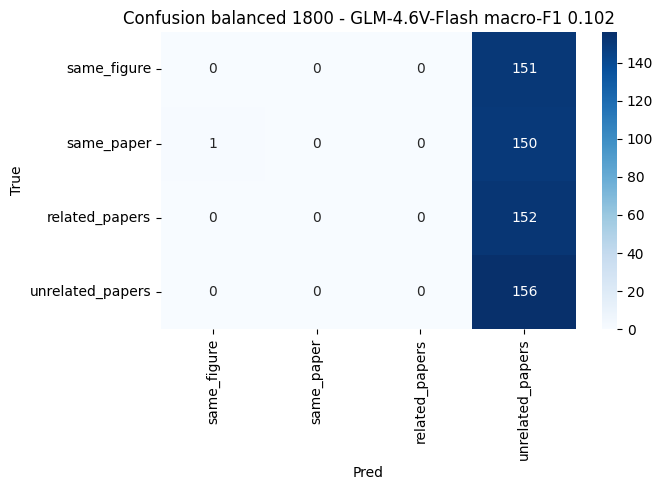

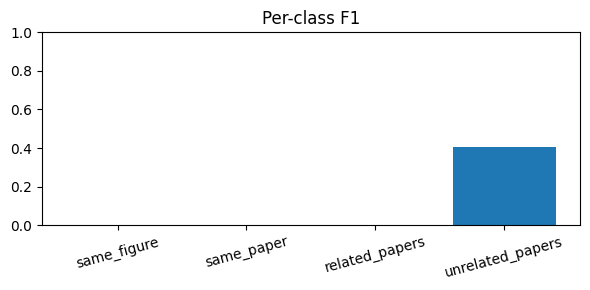

IndexError: boolean index did not match indexed array along axis 0; size of axis is 610 but size of corresponding boolean axis is 1800

In [11]:
# --- 9. Visualization ---
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_cols, yticklabels=label_cols)
plt.title(f"Confusion balanced 1800 - {MODEL_ID.split('/')[-1]} macro-F1 {macro_f1:.3f}")
plt.ylabel("True"); plt.xlabel("Pred"); plt.tight_layout(); plt.savefig("confusion.png", dpi=150); plt.show()

plt.figure(figsize=(6,3))
plt.bar(label_cols, per_class)
plt.title("Per-class F1"); plt.ylim(0,1); plt.xticks(rotation=15); plt.tight_layout(); plt.savefig("per_class_f1.png"); plt.show()

# Per pair_type F1
pts, f1s = [], []
for pt in ["TXT-IMG","IMG-IMG","TXT-TXT"]:
    mask = train_bal["pair_type"]==pt
    f1s.append(f1_score(y_true[mask], y_pred[mask], average="macro", zero_division=0))
    pts.append(pt)
plt.figure(figsize=(6,3))
plt.bar(pts, f1s)
plt.title("Macro-F1 per pair_type"); plt.ylim(0,1); plt.tight_layout(); plt.savefig("per_pair_f1.png"); plt.show()

# Caption length vs error
train_bal["correct"] = (y_true == y_pred)
train_bal["obj_1_len"] = train_bal["obj_1"].astype(str).str.len()
plt.figure(figsize=(6,3))
sns.histplot(data=train_bal, x="obj_1_len", hue="correct", bins=30, alpha=0.6)
plt.title("Caption length vs correctness"); plt.tight_layout(); plt.savefig("len_vs_correct.png"); plt.show()
print("Saved plots")

In [ ]:
# --- 10. 6.5h guard + summary (5-7h test) ---
elapsed = (time.time()-start_time)/3600
print(f"Elapsed {elapsed:.2f}h / 6.5h budget, remaining {6.5-elapsed:.2f}h")
print(f"Model {MODEL_ID} batch {BATCH_SIZE} thinking {ENABLE_THINKING} on balanced 1800 (450/class)")
print(f"Balanced macro-F1 {macro_f1:.4f} -> full 10k would be ~34h at 12s/it, use true batch 4 or 4B model for 9h")
print("Outputs: preds_train_bal_final.npy, metrics.json, confusion.png")
